#Carga del dataset

En esta sección se carga el dataset previamente limpio generado en la Parte 1 del proyecto.
Este archivo contiene las variables ya corregidas y listas para el análisis.

In [37]:
import pandas as pd

df = pd.read_csv("/content/sample_data/telecom_data_clean.csv")

df.head()

,customerID,Churn,Genero,Adulto_Mayor,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,account.PaymentMethod,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Churn_binario
0,0002-ORFBO,no,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0.0
1,0003-MKNFE,no,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0.0
2,0004-TLHLJ,yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1.0
3,0011-IGKFF,yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1.0
4,0013-EXCHZ,yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1.0


# Eliminación de columnas irrelevantes

En esta etapa se eliminan las columnas que no aportan valor al análisis o a los modelos predictivos.

En particular, se eliminan los identificadores únicos, como el ID del cliente, ya que no contienen información útil para predecir la cancelación del servicio.
Este tipo de variables solo identifican registros individuales y pueden afectar negativamente el desempeño de modelos de machine learning.

Eliminar estas columnas permite trabajar con un conjunto de datos más limpio y enfocado en las variables realmente relevantes para el análisis de churn.

In [38]:
# Eliminar columnas que no aportan valor al análisis
df = df.drop(columns=["customerID"], errors="ignore")

# Verificar columnas restantes
df.columns

Index(['Churn', 'Genero', 'Adulto_Mayor', 'customer.Partner',
       'customer.Dependents', 'customer.tenure', 'phone.PhoneService',
       'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'Tipo_Contrato',
       'account.PaperlessBilling', 'account.PaymentMethod', 'Cargo_Mensual',
       'Cargo_Total', 'Cuentas_Diarias', 'Churn_binario'],
      dtype='object')

#Encoding

En esta etapa se transforman las variables categóricas a formato numérico para que puedan ser utilizadas por los algoritmos de machine learning.

Muchos modelos de aprendizaje automático solo pueden trabajar con valores numéricos, por lo que es necesario convertir variables categóricas como el tipo de contrato, el método de pago o el género en representaciones numéricas.

Para ello se utiliza el método **One-Hot Encoding**, que crea nuevas columnas binarias (0 y 1) para cada categoría presente en las variables categóricas. Este método evita introducir un orden artificial entre las categorías y es ampliamente utilizado en problemas de clasificación.

In [39]:
# Seleccionar columnas categóricas
columnas_categoricas = df.select_dtypes(include=["object"]).columns

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# Ver las primeras filas del dataset transformado
df_encoded.head()

,Adulto_Mayor,customer.tenure,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Churn_binario,Churn_yes,Genero_Male,customer.Partner_Yes,customer.Dependents_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.186667,0.0,False,False,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,1.996667,0.0,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,1.0,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.266667,1.0,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.796667,1.0,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


#Verificación del dataset transformado

Después de aplicar el proceso de codificación, verificamos la estructura del nuevo dataset para confirmar que todas las variables categóricas fueron transformadas correctamente a variables numéricas.

In [40]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 33 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Adulto_Mayor                                   7267 non-null   int64  
 1   customer.tenure                                7267 non-null   int64  
 2   Cargo_Mensual                                  7267 non-null   float64
 3   Cargo_Total                                    7256 non-null   float64
 4   Cuentas_Diarias                                7267 non-null   float64
 5   Churn_binario                                  7043 non-null   float64
 6   Churn_yes                                      7267 non-null   bool   
 7   Genero_Male                                    7267 non-null   bool   
 8   customer.Partner_Yes                           7267 non-null   bool   
 9   customer.Dependents_Yes                        7267 

#Verificación de la Proporción de Cancelación (Churn)

En esta etapa se analiza la proporción de clientes que cancelaron el servicio (Churn) frente a aquellos que permanecen activos.

Este análisis es importante porque permite identificar si existe un desbalance entre las clases. Cuando una clase es mucho más frecuente que la otra, los modelos de machine learning pueden verse afectados, ya que tienden a predecir con mayor frecuencia la clase dominante.

Comprender este balance es clave para decidir si será necesario aplicar técnicas adicionales como balanceo de clases, muestreo o métricas de evaluación específicas.

In [41]:
# Conteo de clases
conteo_churn = df["Churn"].value_counts()

print("Cantidad de clientes por clase:")
print(conteo_churn)

Cantidad de clientes por clase:
Churn
no     5174
yes    1869
Name: count, dtype: int64


#Proporción de cada clase

Además del conteo absoluto de clientes que cancelaron o permanecieron, se calcula la proporción de cada clase para comprender mejor la distribución relativa del churn en el dataset.

In [42]:
# Proporción de churn
proporcion_churn = df["Churn"].value_counts(normalize=True)

print("Proporción de clientes por clase:")
print(proporcion_churn)

Proporción de clientes por clase:
Churn
no     0.73463
yes    0.26537
Name: proportion, dtype: float64


#Visualización del balance de clases

Para facilitar la interpretación de la distribución de churn, se genera una visualización que muestra la cantidad de clientes que cancelaron el servicio frente a aquellos que permanecieron activos.

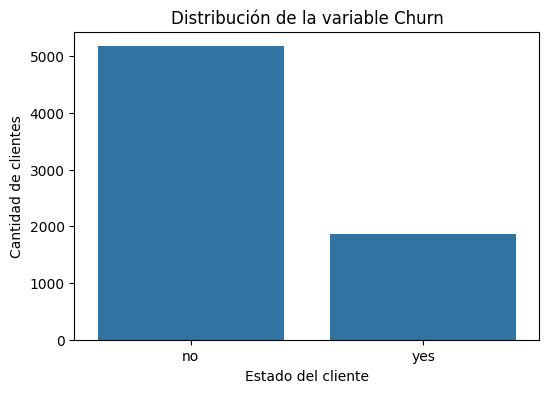

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Distribución de la variable Churn")
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad de clientes")

plt.show()

#Análisis de correlación entre variables

En esta etapa se analiza la correlación entre las variables numéricas del dataset.
La matriz de correlación permite identificar relaciones entre variables y detectar cuáles tienen mayor relación con la variable objetivo (Churn).

Una correlación alta indica que dos variables tienden a variar juntas.
En particular, es importante observar qué variables muestran mayor correlación con la cancelación del servicio, ya que podrían ser buenos predictores para los modelos de machine learning.

Para facilitar la interpretación, se utilizará un mapa de calor (heatmap) que permite visualizar la intensidad de las correlaciones entre las variables.

In [44]:
# Calcular matriz de correlación
correlation_matrix = df_encoded.corr()

correlation_matrix.head()

,Adulto_Mayor,customer.tenure,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Churn_binario,Churn_yes,Genero_Male,customer.Partner_Yes,customer.Dependents_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
Adulto_Mayor,1.000000,0.018187,0.220388,0.103499,0.220388,0.150889,0.146733,-0.004288,0.022970,-0.212952,...,-0.182697,0.103655,-0.182697,0.119374,-0.046832,-0.114837,0.157734,-0.022698,0.170705,-0.154216
customer.tenure,0.018187,1.000000,0.247982,0.825118,0.247982,-0.352229,-0.344079,0.005765,0.377551,0.159892,...,-0.037029,0.280738,-0.037029,0.286841,0.205970,0.557675,0.007949,0.235319,-0.207056,-0.234305
Cargo_Mensual,0.220388,0.247982,1.000000,0.652109,1.000000,0.193356,0.189866,-0.013889,0.097122,-0.115832,...,-0.763772,0.628874,-0.763772,0.628184,0.008758,-0.077935,0.353714,0.031610,0.275550,-0.378635
Cargo_Total,0.103499,0.825118,0.652109,1.000000,0.652109,-0.199484,-0.194440,0.000488,0.316918,0.063960,...,-0.374618,0.516900,-0.374618,0.521245,0.175040,0.354547,0.159303,0.184990,-0.057178,-0.295076
Cuentas_Diarias,0.220388,0.247982,1.000000,0.652109,1.000000,0.193356,0.189866,-0.013889,0.097122,-0.115832,...,-0.763772,0.628874,-0.763772,0.628184,0.008758,-0.077935,0.353714,0.031610,0.275550,-0.378635


A continuación se visualiza la matriz de correlación mediante un mapa de calor.
Los colores más intensos indican una correlación más fuerte entre las variables.

Esto permite identificar rápidamente qué variables podrían estar más relacionadas con la evasión de clientes.

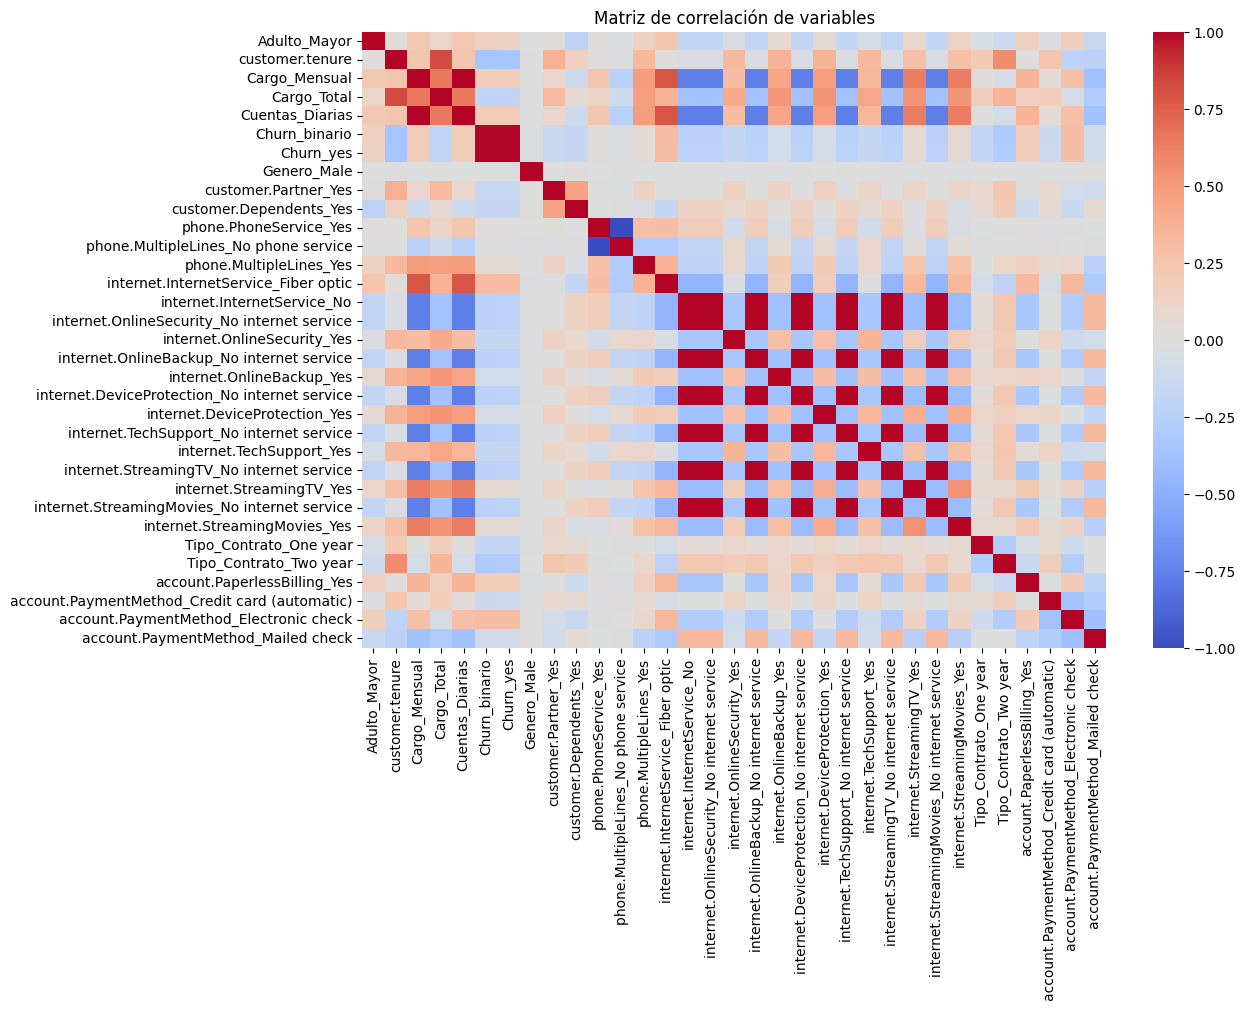

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de correlación de variables")

plt.show()

Para identificar con mayor claridad qué variables tienen mayor relación con la cancelación del servicio, se ordenan las correlaciones respecto a la variable objetivo (Churn).

In [46]:
# Correlación con churn
correlation_matrix["Churn_binario"].sort_values(ascending=False)

,Churn_binario
Churn_yes,1.000000
Churn_binario,1.000000
internet.InternetService_Fiber optic,0.308020
account.PaymentMethod_Electronic check,0.301919
Cargo_Mensual,0.193356
Cuentas_Diarias,0.193356
account.PaperlessBilling_Yes,0.191825
Adulto_Mayor,0.150889
internet.StreamingTV_Yes,0.063228
internet.StreamingMovies_Yes,0.061382


#Análisis dirigido de variables relacionadas con la cancelación

En esta etapa se realiza un análisis dirigido para investigar cómo ciertas variables específicas se relacionan con la cancelación del servicio (Churn).

Se analizarán particularmente:
- Tiempo de contrato (tenure)
- Gasto total del cliente

Estas variables pueden influir en la probabilidad de que un cliente cancele el servicio.

Para visualizar posibles patrones o tendencias se utilizarán gráficos como boxplots y scatter plots, que permiten comparar cómo se distribuyen estas variables entre clientes que cancelaron y los que permanecen activos.

#Tiempo de contrato vs Cancelación

A continuación se analiza la relación entre el tiempo de contrato del cliente (tenure) y la cancelación del servicio.

Este gráfico permite observar si los clientes con menor antigüedad presentan una mayor tendencia a cancelar el servicio.

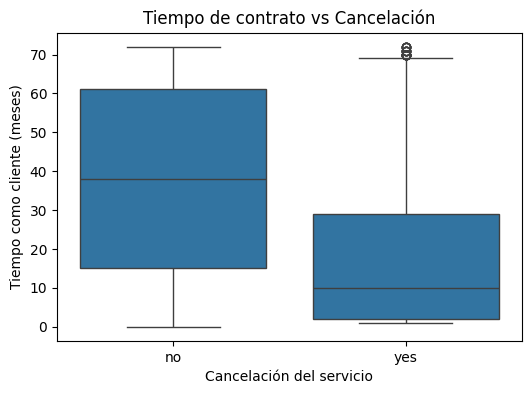

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="customer.tenure", data=df)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación del servicio")
plt.ylabel("Tiempo como cliente (meses)")

plt.show()

#Gasto total vs Cancelación

En este gráfico se analiza cómo se distribuye el gasto total de los clientes en función de si cancelaron o no el servicio.

Esto permite identificar si los clientes que cancelan tienden a tener un gasto total menor o mayor en comparación con aquellos que permanecen activos.

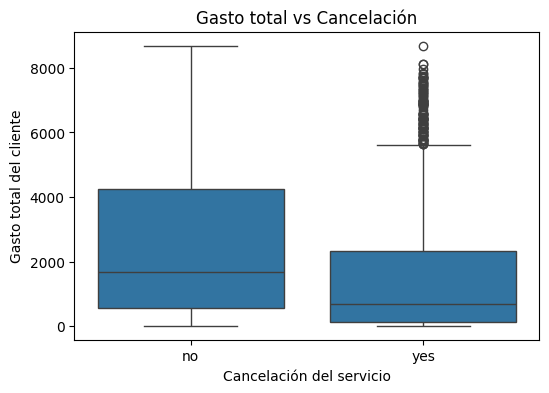

In [48]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="Cargo_Total", data=df)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Cancelación del servicio")
plt.ylabel("Gasto total del cliente")

plt.show()

#Scatter plot: Tiempo de contrato vs Gasto total

Finalmente, se utiliza un gráfico de dispersión para observar la relación entre el tiempo de contrato y el gasto total del cliente, diferenciando a los clientes según su estado de cancelación.

Este gráfico permite identificar posibles patrones entre estas variables y el comportamiento de churn.

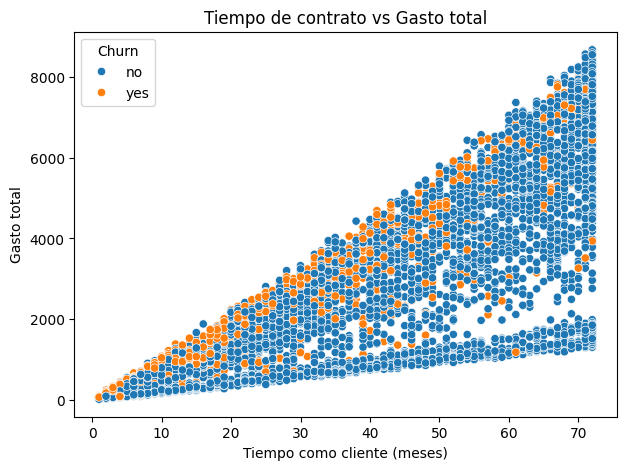

In [49]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="customer.tenure",
    y="Cargo_Total",
    hue="Churn",
    data=df
)

plt.title("Tiempo de contrato vs Gasto total")
plt.xlabel("Tiempo como cliente (meses)")
plt.ylabel("Gasto total")

plt.show()

#Separación de datos para entrenamiento y prueba

En esta etapa se divide el dataset en dos subconjuntos: entrenamiento y prueba.

La división del dataset permite entrenar el modelo utilizando una parte de los datos y evaluar su rendimiento utilizando datos que el modelo no ha visto previamente.

Esto es fundamental para verificar si el modelo tiene capacidad de generalización y no está simplemente memorizando los datos de entrenamiento.

En este caso se utilizará una división del 70% de los datos para entrenamiento y el 30% para prueba, una proporción comúnmente utilizada en problemas de machine learning.

In [50]:
# Variable objetivo
y = df_encoded["Churn_binario"]

# Variables predictoras (todas las demás columnas)
X = df_encoded.drop("Churn_binario", axis=1)

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (7267, 32)
Dimensión de y: (7267,)


#Dividir dataset en entrenamiento y prueba

A continuación se utiliza la función train_test_split de scikit-learn para dividir los datos en conjuntos de entrenamiento y prueba.

El conjunto de entrenamiento será utilizado para construir el modelo, mientras que el conjunto de prueba se utilizará posteriormente para evaluar su desempeño.

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5086, 32)
Datos de prueba: (2181, 32)


#Creación de modelos predictivos

En esta etapa se construyen modelos de machine learning para predecir la cancelación de clientes (Churn).

Se utilizarán dos tipos de modelos:

1. Regresión Logística  
   Este modelo es sensible a la escala de los datos, por lo que se aplicará un proceso de normalización para asegurar que todas las variables tengan una magnitud comparable.

2. Árbol de Decisión  
   Este modelo no depende de la escala de las variables, por lo que no es necesario aplicar normalización.

Comparar ambos modelos permitirá analizar cuál ofrece un mejor desempeño para predecir la cancelación de clientes.

#Normalización de datos

La normalización se utiliza para escalar las variables numéricas a una misma escala.
Esto es importante en modelos como la Regresión Logística o KNN, ya que estos algoritmos pueden verse afectados si algunas variables tienen magnitudes mucho mayores que otras.

Para ello se utiliza StandardScaler, que transforma los datos para que tengan media 0 y desviación estándar 1.

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Limpieza rápida antes de entrenar modelos

Antes de entrenar los modelos se eliminan los registros que contienen valores faltantes (NaN).
Los algoritmos de machine learning de scikit-learn no pueden procesar valores nulos, por lo que es necesario limpiar el dataset antes del entrenamiento.

In [53]:
# eliminar registros con valores nulos
df_encoded = df_encoded.dropna()

#Volver a crear X e y

In [54]:
# variable objetivo
y = df_encoded["Churn_binario"]

# variables predictoras
X = df_encoded.drop("Churn_binario", axis=1)

#Volver a separar entrenamiento y prueba

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

#Arbol de decisión

In [57]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(random_state=42)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

In [58]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

#Precisión del modelo

Para evaluar el desempeño del modelo se calcula la precisión (accuracy), que indica el porcentaje de predicciones correctas realizadas por el modelo.

In [59]:
from sklearn.metrics import accuracy_score

accuracy_arbol = accuracy_score(y_test, pred_arbol)

print("Accuracy del Árbol de Decisión:", accuracy_arbol)

Accuracy del Árbol de Decisión: 1.0


#Matriz de confusión

La matriz de confusión permite analizar cuántos clientes fueron correctamente clasificados y cuántos fueron clasificados incorrectamente por el modelo.

In [60]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, pred_arbol)

print(conf_matrix)

[[1554    0]
 [   0  556]]


#Versión visual de la matriz

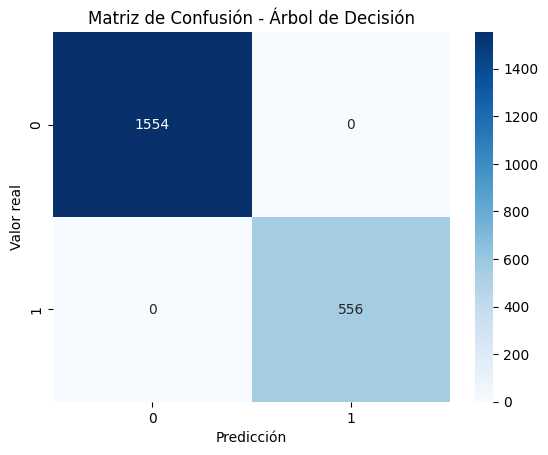

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()